# *Predicting Loan Approval Using Logistic Regression and Decision Tree with GridSearch Optimization* 

# Data Preparation and Preprocessing

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, KFold
import mlflow

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import BaggingClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [3]:
df = pd.read_csv('loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [5]:
df['loan_id'].duplicated().sum()

np.int64(0)

In [6]:
df = df.drop('loan_id', axis=1)

In [7]:
num_f = ['income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value',
         'luxury_assets_value', 'bank_asset_value']
cat_f = ['no_of_dependents','education', 'self_employed', 'loan_status']

In [8]:
df.isna().sum().sum()

np.int64(0)

In [9]:
columns = df.columns

In [10]:
df.columns = columns.str.lower().str.strip()

In [11]:
# columns need encoding
#  2    education                 4269 non-null   object
#  3    self_employed             4269 non-null   object
#  12   loan_status               4269 non-null   object
df['education'].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [12]:
df['self_employed'].value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [13]:
print(df['education'].unique()) # look at the output, we have some spaces that need to be stripped

[' Graduate' ' Not Graduate']


In [14]:
df['education'] = df['education'].str.strip()
df['self_employed'] = df['self_employed'].str.strip()
df['loan_status'] = df['loan_status'].str.strip()

df['education'] = df['education'].map({'Graduate': 1, 'Not Graduate': 0})
df['self_employed'] = df['self_employed'].map({'Yes': 1, 'No': 0})
df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

df[['education','self_employed','loan_status']] = df[['education','self_employed','loan_status']].astype(int)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   int64
 2   self_employed             4269 non-null   int64
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   int64
dtypes: int64(12)
memory usage: 400.3 KB


In [16]:
scaler = StandardScaler()
df[num_f]=scaler.fit_transform(df[num_f])

In [17]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,1.617979,1.633052,0.192617,1.032792,-0.780058,2.877289,0.832028,0.930304,1
1,0,0,1,-0.341750,-0.324414,-0.508091,-1.061051,-0.733924,-0.631921,-0.694993,-0.515936,0
2,3,1,0,1.439822,1.610933,1.594031,-0.544840,-0.057300,-0.107818,1.996520,2.407316,0
3,3,1,0,1.119139,1.721525,-0.508091,-0.771045,1.649637,-0.381263,0.897943,0.899533,0
4,5,0,1,1.689242,1.002681,1.594031,-1.264055,0.757724,0.735304,1.568075,0.007172,0


# Train Test Split and Utility Functions

In [18]:
x = df.drop('loan_status', axis=1)
y = df['loan_status']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=7, stratify=y)

In [19]:
def eval(y_test, y_pred):
  acc = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1_val = f1_score(y_test, y_pred)
  f1_macro = f1_score(y_test, y_pred, average='macro')
  cm = confusion_matrix(y_test, y_pred)

  metrics = {'accuracy_score':acc,
             'precision_score':precision,
             'recall_score':recall,
             'f1_score':f1_val,
             'f1_macro':f1_macro}
  print(classification_report(y_test, y_pred))

  return metrics, cm

In [20]:
def grid_search(model, param_grid):
    
    kf = KFold(n_splits=5, shuffle=True, random_state=7)

    grid_search = GridSearchCV(model, param_grid=param_grid, cv=kf, scoring='f1')
    grid_search.fit(x_train, y_train)
 
    print(f'Best Parameters: {grid_search.best_params_}')
    print(f'Best F1 Score: {grid_search.best_score_}')
    print(f'Feature Importances: {getattr(grid_search.best_estimator_, "feature_importances_", "N/A")}')
    return grid_search.best_estimator_

In [21]:
def plot_confusion_matrix(model, cm):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {model.__class__.__name__}')
    plt.show()

# Logistic Regression Model

## Baseline Model Without Regularization

In [22]:
log_reg = LogisticRegression(penalty='l2', C=1, solver='lbfgs', max_iter=1000, random_state=7) # random params
log_reg.fit(x_train, y_train)

y_pred = log_reg.predict(x_test)
metrics, cm = eval(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       484
           1       0.94      0.93      0.93       797

    accuracy                           0.92      1281
   macro avg       0.91      0.92      0.91      1281
weighted avg       0.92      0.92      0.92      1281



## Optimizing Model Parameters Using GridSearchCV

Best Parameters: {'C': 0.1, 'l1_ratio': 0, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1 Score: 0.9375824108374212
Feature Importances: N/A
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       484
           1       0.94      0.93      0.93       797

    accuracy                           0.92      1281
   macro avg       0.91      0.92      0.91      1281
weighted avg       0.92      0.92      0.92      1281



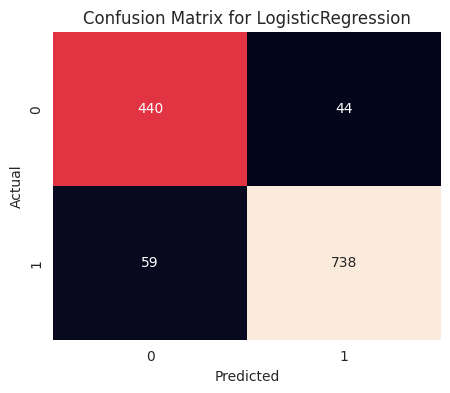

In [23]:
log_param_grid = {
    'C':[0.001, 0.01, 0.1, 1, 10, 100],
    'penalty':['l1', 'l2'],
    'solver':['lbfgs', 'liblinear'],
    'l1_ratio':[0, 0.5, 1]
}

best_log = grid_search(log_reg, log_param_grid)
y_pred = best_log.predict(x_test)

metrics, cm = eval(y_test, y_pred)
plot_confusion_matrix(best_log, cm)

# Decision Tree Model

## Baseline Model

In [24]:
DT = DecisionTreeClassifier(criterion='gini', random_state=7) # same as logistic for some test we put random params
DT.fit(x_train, y_train)

y_pred = DT.predict(x_test)
metrics, cm = eval(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       484
           1       0.98      0.97      0.98       797

    accuracy                           0.97      1281
   macro avg       0.97      0.97      0.97      1281
weighted avg       0.97      0.97      0.97      1281



## Hyperparameter Tuning with GridSearchCV

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_leaf_nodes': 20, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best F1 Score: 0.9852129445927176
Feature Importances: [0.         0.         0.         0.02216158 0.03033183 0.12331914
 0.80161812 0.01762605 0.00494327 0.         0.        ]
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       484
           1       0.97      0.98      0.98       797

    accuracy                           0.97      1281
   macro avg       0.97      0.97      0.97      1281
weighted avg       0.97      0.97      0.97      1281



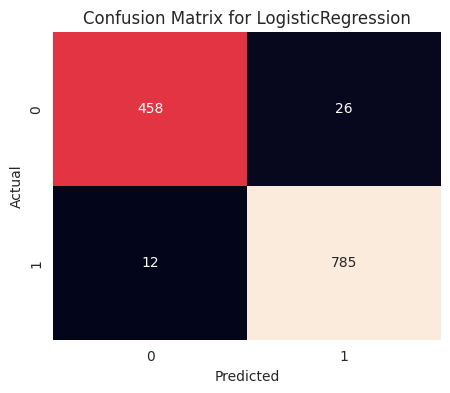

In [ ]:
grid_params = {'criterion':['gini', 'entropy'],
               'max_depth':[3, 4, 5, 6, 7, 8, 9, 10],
               'min_samples_split':[2,3,4,6,8,10],
               'min_samples_leaf':[1,2,3,4,5],
               'max_leaf_nodes':[None, 10, 20, 30, 40, 50]}

best_DT = grid_search(DT, grid_params)
y_pred = best_DT.predict(x_test)

metrics, cm = eval(y_test, y_pred)
plot_confusion_matrix(best_log, cm)

# Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_leaf_nodes': 20, 'min_samples_leaf': 2, 'min_samples_split': 2}
# Best F1 Score: 0.9852129445927176
# Feature Importances: [0.         0.         0.         0.02216158 0.03033183 0.12331914
#  0.80161812 0.01762605 0.00494327 0.         0.        ]
#               precision    recall  f1-score   support

#            0       0.97      0.95      0.96       484
#            1       0.97      0.98      0.98       797

#     accuracy                           0.97      1281
#    macro avg       0.97      0.97      0.97      1281
# weighted avg       0.97      0.97      0.97      1281


In [26]:
RANDOM_STATE = 7

ada_boost_params = {'estimator':best_DT, 'n_estimators':100, 'learning_rate':0.1}
random_forest_params = {'n_estimators':100, 'max_depth':5, 'min_samples_split':4, 'min_samples_leaf':2}
gradient_boost_params = {'n_estimators':100, 'learning_rate':0.1}
xgboost_params = {'n_estimators':100, 'learning_rate':0.1}

In [27]:
models = {
    'Logistic Regression': best_log,
    'Decision Tree': best_DT,
    'AdaBoost': AdaBoostClassifier(**ada_boost_params, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(**random_forest_params, random_state=RANDOM_STATE),
    'XGBoost Classifier': XGBClassifier(**xgboost_params, random_state=RANDOM_STATE)
}

In [28]:
for model_name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    metrics, cm = eval(y_test, y_pred)
    print(f'{model_name} Metrics: {metrics}')
    # plot_confusion_matrix(model, cm)

              precision    recall  f1-score   support

           0       0.88      0.91      0.90       484
           1       0.94      0.93      0.93       797

    accuracy                           0.92      1281
   macro avg       0.91      0.92      0.91      1281
weighted avg       0.92      0.92      0.92      1281

Logistic Regression Metrics: {'accuracy_score': 0.9195940671350508, 'precision_score': 0.9437340153452686, 'recall_score': 0.9259723964868256, 'f1_score': 0.934768841038632, 'f1_macro': 0.9149937796240972}
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       484
           1       0.97      0.98      0.98       797

    accuracy                           0.97      1281
   macro avg       0.97      0.97      0.97      1281
weighted avg       0.97      0.97      0.97      1281

Decision Tree Metrics: {'accuracy_score': 0.970335675253708, 'precision_score': 0.967940813810111, 'recall_score': 0.9849435382685069, 'f1_s

In [29]:
mlflow.set_tracking_uri('http://127.0.0.1:5000/')
mlflow.set_experiment('Loan Approval Prediction')

for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):
        y_pred = model.predict(x_test)
        metrics, cm = eval(y_test, y_pred)
        mlflow.log_params(model.get_params())
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(model, model_name)
        
        print(f'{model_name} Metrics: {metrics}')
        # plot_confusion_matrix(model, cm)

2026/03/06 02:33:51 INFO mlflow.tracking.fluent: Experiment with name 'Loan Approval Prediction' does not exist. Creating a new experiment.
2026/03/06 02:33:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


              precision    recall  f1-score   support

           0       0.88      0.91      0.90       484
           1       0.94      0.93      0.93       797

    accuracy                           0.92      1281
   macro avg       0.91      0.92      0.91      1281
weighted avg       0.92      0.92      0.92      1281



2026/03/06 02:33:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression Metrics: {'accuracy_score': 0.9195940671350508, 'precision_score': 0.9437340153452686, 'recall_score': 0.9259723964868256, 'f1_score': 0.934768841038632, 'f1_macro': 0.9149937796240972}
🏃 View run Logistic Regression at: http://127.0.0.1:5000/#/experiments/1/runs/5ed6c18fa3824eed95c9a4e8aa763f27
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/03/06 02:33:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

Random Forest Metrics: {'accuracy_score': 0.9617486338797814, 'precision_score': 0.9934036939313984, 'recall_score': 0.944792973651192, 'f1_score': 0.9684887459807074, 'f1_macro': 0.9599146808354382}
🏃 View run Random Forest at: http://127.0.0.1:5000/#/experiments/1/runs/a7f86062faf2477d879281d211a01418
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/03/06 02:34:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


              precision    recall  f1-score   support

           0       0.98      0.98      0.98       484
           1       0.98      0.99      0.99       797

    accuracy                           0.98      1281
   macro avg       0.98      0.98      0.98      1281
weighted avg       0.98      0.98      0.98      1281



2026/03/06 02:34:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost Classifier Metrics: {'accuracy_score': 0.9820452771272443, 'precision_score': 0.9849624060150376, 'recall_score': 0.986198243412798, 'f1_score': 0.9855799373040752, 'f1_macro': 0.9808975177730304}
🏃 View run XGBoost Classifier at: http://127.0.0.1:5000/#/experiments/1/runs/31f5df9a726144b48be62e9854a233fa
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
